In [1]:
import pandas as pd

df = pd.read_csv('../../dataset/PSML.csv')
df['time'] = pd.to_datetime(df['time'])

# 2) Select every 43800th row from that column
every_43800 = df['time'].iloc[::43800]

# 3) Convert to "MM/DD/YYYY" strings and store as a list
formatted_dates = every_43800.dt.strftime('%m/%d/%Y').tolist()
formatted_dates.pop(0)
formatted_dates.pop(-1)
formatted_dates

['01/31/2018',
 '03/02/2018',
 '04/02/2018',
 '05/02/2018',
 '06/02/2018',
 '07/02/2018',
 '08/01/2018',
 '09/01/2018',
 '10/01/2018',
 '11/01/2018',
 '12/01/2018',
 '01/01/2019',
 '02/01/2019',
 '03/03/2019',
 '04/03/2019',
 '05/03/2019',
 '06/03/2019',
 '07/03/2019',
 '08/02/2019',
 '09/02/2019',
 '10/02/2019',
 '11/02/2019',
 '12/02/2019',
 '01/02/2020',
 '02/02/2020',
 '03/03/2020',
 '04/03/2020',
 '05/03/2020',
 '06/03/2020',
 '07/03/2020',
 '08/02/2020',
 '09/02/2020',
 '10/02/2020',
 '11/02/2020']

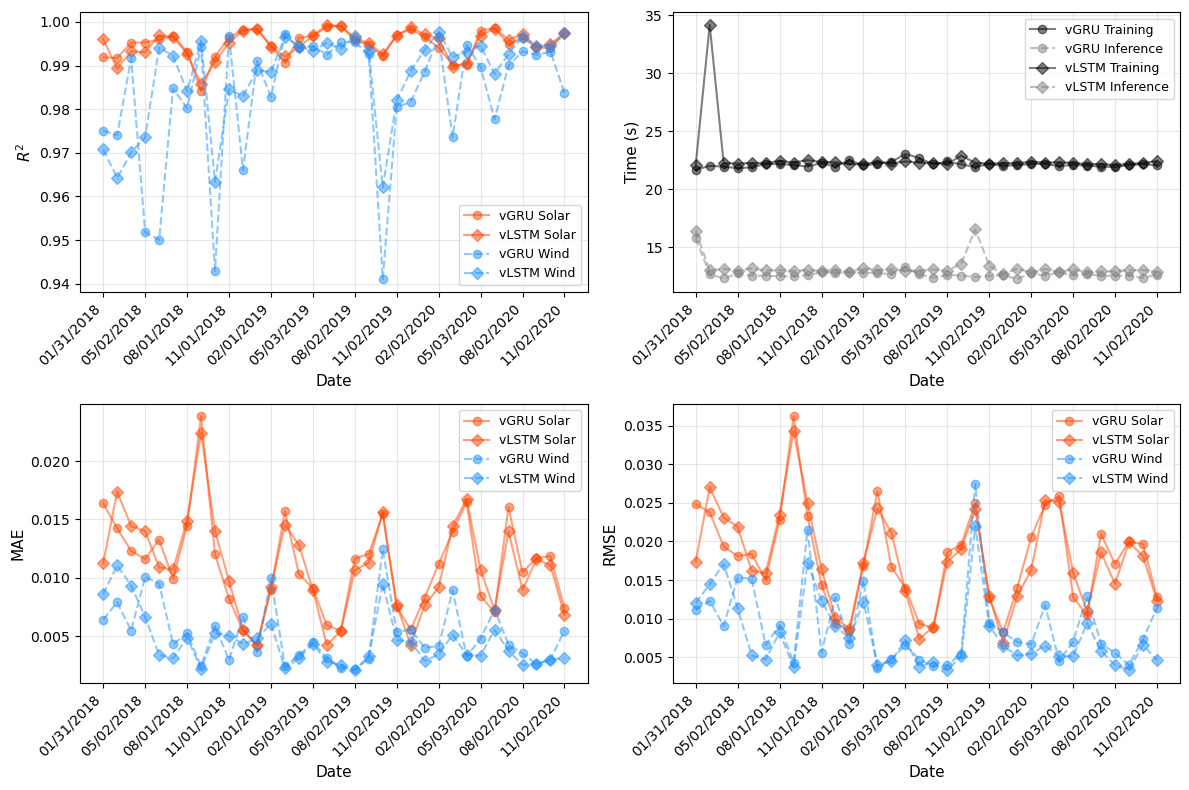

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Load both .npz files
vgru_data  = np.load('vgru_rolling_session_outputs/vgru_rolling_metrics.npz')
vlstm_data = np.load('vlstm_rolling_session_outputs/vlstm_rolling_metrics.npz')

# Extract common session numbers
session_nums = vgru_data['session_nums']
session_dates = formatted_dates

# VGRU metrics
r2_solar_vgru    = vgru_data['r2_solar']
r2_wind_vgru     = vgru_data['r2_wind']
mae_solar_vgru   = vgru_data['mae_solar']
mae_wind_vgru    = vgru_data['mae_wind']
rmse_solar_vgru  = vgru_data['rmse_solar']
rmse_wind_vgru   = vgru_data['rmse_wind']
train_time_vgru  = vgru_data['training_times']
infer_time_vgru  = vgru_data['inference_times']

# vLSTM metrics
r2_solar_vlstm    = vlstm_data['r2_solar']
r2_wind_vlstm     = vlstm_data['r2_wind']
mae_solar_vlstm   = vlstm_data['mae_solar']
mae_wind_vlstm    = vlstm_data['mae_wind']
rmse_solar_vlstm  = vlstm_data['rmse_solar']
rmse_wind_vlstm   = vlstm_data['rmse_wind']
train_time_vlstm  = vlstm_data['training_times']
infer_time_vlstm  = vlstm_data['inference_times']

# 2) Create 2×2 subplot grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
ax_r2, ax_time, ax_mae, ax_rmse = axes.flatten()

# 3) Define colors and markers
color_solar = 'orangered'
color_wind  = 'dodgerblue'
marker_vgru = 'o'
marker_vlstm = 'D'
alpha_val = 0.5

# 4) Determine indices for every third tick
tick_indices = np.arange(0, len(session_nums), 3)

# -----------------------------------
# Helper to set every-3rd date tick labels
# -----------------------------------
def set_date_xticks(ax):
    ax.set_xticks([session_nums[i] for i in tick_indices])
    ax.set_xticklabels([session_dates[i] for i in tick_indices],
                       rotation=45, ha='right', fontsize=10)

# -----------------------------------
# Top‐Left: R² (single axis)
# -----------------------------------
ax_r2.plot(
    session_nums,
    r2_solar_vgru,
    color=color_solar,
    marker=marker_vgru,
    linestyle='-',
    alpha=alpha_val,
    label='vGRU Solar'
)
ax_r2.plot(
    session_nums,
    r2_solar_vlstm,
    color=color_solar,
    marker=marker_vlstm,
    linestyle='-',
    alpha=alpha_val,
    label='vLSTM Solar'
)
ax_r2.plot(
    session_nums,
    r2_wind_vgru,
    color=color_wind,
    marker=marker_vgru,
    linestyle='--',
    alpha=alpha_val,
    label='vGRU Wind'
)
ax_r2.plot(
    session_nums,
    r2_wind_vlstm,
    color=color_wind,
    marker=marker_vlstm,
    linestyle='--',
    alpha=alpha_val,
    label='vLSTM Wind'
)
ax_r2.set_xlabel('Date', color='black', fontsize=11)
ax_r2.set_ylabel(r'$R^2$', color='black', fontsize=11)
#ax_r2.set_title('R² vs. Date', fontsize=13)
ax_r2.legend(loc='best', fontsize=9)
ax_r2.grid(alpha=0.3)
set_date_xticks(ax_r2)

# -----------------------------------
# Top‐Right: Training & Inference Time
# -----------------------------------
ax_time.plot(
    session_nums,
    train_time_vgru,
    color='k',
    marker=marker_vgru,
    linestyle='-',
    alpha=alpha_val,
    label='vGRU Training'
)
ax_time.plot(
    session_nums,
    infer_time_vgru,
    color='gray',
    marker=marker_vgru,
    linestyle='--',
    alpha=alpha_val,
    label='vGRU Inference'
)
ax_time.plot(
    session_nums,
    train_time_vlstm,
    color='k',
    marker=marker_vlstm,
    linestyle='-',
    alpha=alpha_val,
    label='vLSTM Training'
)
ax_time.plot(
    session_nums,
    infer_time_vlstm,
    color='gray',
    marker=marker_vlstm,
    linestyle='--',
    alpha=alpha_val,
    label='vLSTM Inference'
)
ax_time.set_xlabel('Date', color='black', fontsize=11)
ax_time.set_ylabel('Time (s)', color='black', fontsize=11)
#ax_time.set_title('Training & Inference Time vs. Date', fontsize=13)
ax_time.legend(loc='best', fontsize=9)
ax_time.grid(alpha=0.3)
set_date_xticks(ax_time)

# -----------------------------------
# Bottom‐Left: MAE (single axis, unitless)
# -----------------------------------
ax_mae.plot(
    session_nums,
    mae_solar_vgru,
    color=color_solar,
    marker=marker_vgru,
    linestyle='-',
    alpha=alpha_val,
    label='vGRU Solar'
)
ax_mae.plot(
    session_nums,
    mae_solar_vlstm,
    color=color_solar,
    marker=marker_vlstm,
    linestyle='-',
    alpha=alpha_val,
    label='vLSTM Solar'
)
ax_mae.plot(
    session_nums,
    mae_wind_vgru,
    color=color_wind,
    marker=marker_vgru,
    linestyle='--',
    alpha=alpha_val,
    label='vGRU Wind'
)
ax_mae.plot(
    session_nums,
    mae_wind_vlstm,
    color=color_wind,
    marker=marker_vlstm,
    linestyle='--',
    alpha=alpha_val,
    label='vLSTM Wind'
)
ax_mae.set_xlabel('Date', color='black', fontsize=11)
ax_mae.set_ylabel('MAE', color='black', fontsize=11)
#ax_mae.set_title('MAE vs. Date', fontsize=13)
ax_mae.legend(loc='best', fontsize=9)
ax_mae.grid(alpha=0.3)
set_date_xticks(ax_mae)

# -----------------------------------
# Bottom‐Right: RMSE (single axis, unitless)
# -----------------------------------
ax_rmse.plot(
    session_nums,
    rmse_solar_vgru,
    color=color_solar,
    marker=marker_vgru,
    linestyle='-',
    alpha=alpha_val,
    label='vGRU Solar'
)
ax_rmse.plot(
    session_nums,
    rmse_solar_vlstm,
    color=color_solar,
    marker=marker_vlstm,
    linestyle='-',
    alpha=alpha_val,
    label='vLSTM Solar'
)
ax_rmse.plot(
    session_nums,
    rmse_wind_vgru,
    color=color_wind,
    marker=marker_vgru,
    linestyle='--',
    alpha=alpha_val,
    label='vGRU Wind'
)
ax_rmse.plot(
    session_nums,
    rmse_wind_vlstm,
    color=color_wind,
    marker=marker_vlstm,
    linestyle='--',
    alpha=alpha_val,
    label='vLSTM Wind'
)
ax_rmse.set_xlabel('Date', color='black', fontsize=11)
ax_rmse.set_ylabel('RMSE', color='black', fontsize=11)
#ax_rmse.set_title('RMSE vs. Date', fontsize=13)
ax_rmse.legend(loc='best', fontsize=9)
ax_rmse.grid(alpha=0.3)
set_date_xticks(ax_rmse)

# 5) Final layout & show
plt.tight_layout()
fig.savefig('PSML_rolling_metrics.png', dpi=300, bbox_inches='tight')
plt.show()